## German UCL

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import pickle

In [2]:
# load dataset
import pandas as pd
import numpy as np

df = pd.read_csv("german_credit_risk.csv")

df.head()

,Unnamed: 0,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
0,0,67,male,2,own,NaN,little,1169,6,radio/TV,good
1,1,22,female,2,own,little,moderate,5951,48,radio/TV,bad
2,2,49,male,1,own,little,NaN,2096,12,education,good
3,3,45,male,2,free,little,little,7882,42,furniture/equipment,good
4,4,53,male,2,free,little,little,4870,24,car,bad


In [3]:
# Standardize column names (optional but recommended)
df.columns = [col.strip().replace(" ", "_") for col in df.columns]

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Unnamed:_0        1000 non-null   int64 
 1   Age               1000 non-null   int64 
 2   Sex               1000 non-null   object
 3   Job               1000 non-null   int64 
 4   Housing           1000 non-null   object
 5   Saving_accounts   817 non-null    object
 6   Checking_account  606 non-null    object
 7   Credit_amount     1000 non-null   int64 
 8   Duration          1000 non-null   int64 
 9   Purpose           1000 non-null   object
 10  Risk              1000 non-null   object
dtypes: int64(5), object(6)
memory usage: 86.1+ KB


In [4]:
target = "Risk"
df[target] = df[target].map({"good": 0, "bad": 1})

sensitive = "Sex"
# Age-based fairness
# df["age_group"] = df["Age"].apply(lambda x: "young" if x < 25 else "adult")

In [5]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=[target])
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [6]:
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer

categorical_cols = X.select_dtypes(include=["object"]).columns
numeric_cols = X.select_dtypes(exclude=["object"]).columns

preprocessor = ColumnTransformer([
    ("num", StandardScaler(), numeric_cols),
    ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols)
])

In [15]:
# Baseline model
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import pickle

models = {
    "log_reg": LogisticRegression(max_iter=1500),
    "rf": RandomForestClassifier(random_state=42),
    "dt": DecisionTreeClassifier(random_state=42)
}

results = []

for name, model in models.items():
    pipe = Pipeline([
        ("preprocess", preprocessor),
        ("model", model)
    ])
    
    pipe.fit(X_train, y_train)
    preds = pipe.predict(X_test)
    
    # Save model
    with open(f"german_{name}_baseline.pkl", "wb") as f:
        pickle.dump(pipe, f)
    
    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, preds),
        "Precision": precision_score(y_test, preds),
        "Recall": recall_score(y_test, preds),
        "F1": f1_score(y_test, preds)
    })

baseline_perf_df = pd.DataFrame(results)
baseline_perf_df

,Model,Accuracy,Precision,Recall,F1
0,log_reg,0.735,0.594595,0.366667,0.453608
1,rf,0.750,0.638889,0.383333,0.479167
2,dt,0.675,0.460317,0.483333,0.471545


In [16]:
# Fairness metrics
from fairlearn.metrics import demographic_parity_difference, equalized_odds_difference
import numpy as np

def compute_fairness_metrics(y_true, y_pred, sensitive_features):
    dpd = demographic_parity_difference(y_true, y_pred, sensitive_features=sensitive_features)
    eod = equalized_odds_difference(y_true, y_pred, sensitive_features=sensitive_features)
    
    groups = np.unique(sensitive_features)
    rates = []
    
    for g in groups:
        idx = sensitive_features == g
        rates.append(np.mean(y_pred[idx]))
    
    dir_ratio = min(rates) / max(rates) if max(rates) > 0 else 0
    
    return {
        "DPD": round(dpd, 4),
        "EOD": round(eod, 4),
        "DIR": round(dir_ratio, 4)
    }

In [17]:
# baseline evaultion
baseline_fairness = []

for name, model in models.items():
    pipe = Pipeline([
        ("preprocess", preprocessor),
        ("model", model)
    ])
    
    pipe.fit(X_train, y_train)
    preds = pipe.predict(X_test)
    
    fairness = compute_fairness_metrics(
        y_test.values,
        preds,
        X_test[sensitive].values
    )
    
    baseline_fairness.append({
        "Model": name,
        **fairness
    })

baseline_fairness_df = pd.DataFrame(baseline_fairness)
baseline_fairness_df

,Model,DPD,EOD,DIR
0,log_reg,0.1584,0.20,0.4632
1,rf,0.0476,0.10,0.7764
2,dt,0.1600,0.25,0.6245


In [18]:
# reweighting
group_counts = X_train[sensitive].value_counts()
weights = X_train[sensitive].map(lambda x: 1 / group_counts[x])

reweight_model = LogisticRegression(max_iter=1000)

reweight_pipe = Pipeline([
    ("preprocess", preprocessor),
    ("model", reweight_model)
])

reweight_pipe.fit(X_train, y_train, model__sample_weight=weights)

reweight_preds = reweight_pipe.predict(X_test)

In [19]:
# Smote 
from imblearn.over_sampling import SMOTENC

categorical_cols = X.select_dtypes(include=["object"]).columns
cat_indices = [X.columns.get_loc(col) for col in categorical_cols]

X_encoded = pd.get_dummies(X_train)
X_test_encoded = pd.get_dummies(X_test)

X_test_encoded = X_test_encoded.reindex(columns=X_encoded.columns, fill_value=0)

smote = SMOTENC(categorical_features=cat_indices, random_state=42)

X_resampled, y_resampled = smote.fit_resample(X_encoded, y_train)

smote_model = LogisticRegression(max_iter=1000)
smote_model.fit(X_resampled, y_resampled)

smote_preds = smote_model.predict(X_test_encoded)

/home/sidnaik04/Documents/BiasBuster/code_demo/venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [21]:
# threshold optimization
from fairlearn.postprocessing import ThresholdOptimizer

base_model = LogisticRegression(max_iter=5000, solver='lbfgs')
base_model.fit(X_encoded, y_train)

threshold_optimizer = ThresholdOptimizer(
    estimator=base_model,
    constraints="demographic_parity",
    prefit=True
)

threshold_optimizer.fit(
    X_encoded,
    y_train,
    sensitive_features=X_train[sensitive]
)

threshold_preds = threshold_optimizer.predict(
    X_test_encoded,
    sensitive_features=X_test[sensitive]
)


/home/sidnaik04/Documents/BiasBuster/code_demo/venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 5000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=5000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [22]:
# Final comparison table
comparison = []

def evaluate(name, preds):
    return {
        "Strategy": name,
        "Accuracy": accuracy_score(y_test, preds),
        "Precision": precision_score(y_test, preds),
        "Recall": recall_score(y_test, preds),
        "F1": f1_score(y_test, preds),
        **compute_fairness_metrics(y_test.values, preds, X_test[sensitive].values)
    }

# Baseline (logistic)
baseline_model = LogisticRegression(max_iter=1000)
baseline_model.fit(X_encoded, y_train)
baseline_preds = baseline_model.predict(X_test_encoded)

comparison.append(evaluate("Baseline", baseline_preds))
comparison.append(evaluate("Reweighting", reweight_preds))
comparison.append(evaluate("SMOTE", smote_preds))
comparison.append(evaluate("Threshold", threshold_preds))

comparison_df = pd.DataFrame(comparison)
comparison_df

/home/sidnaik04/Documents/BiasBuster/code_demo/venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,Strategy,Accuracy,Precision,Recall,F1,DPD,EOD,DIR
0,Baseline,0.740,0.617647,0.350000,0.446809,0.1328,0.225,0.4937
1,Reweighting,0.705,1.000000,0.016667,0.032787,0.0164,0.050,0.0000
2,SMOTE,0.700,0.500000,0.516667,0.508197,0.2380,0.275,0.4994
3,Threshold,0.755,0.657143,0.383333,0.484211,0.0159,0.100,0.9115


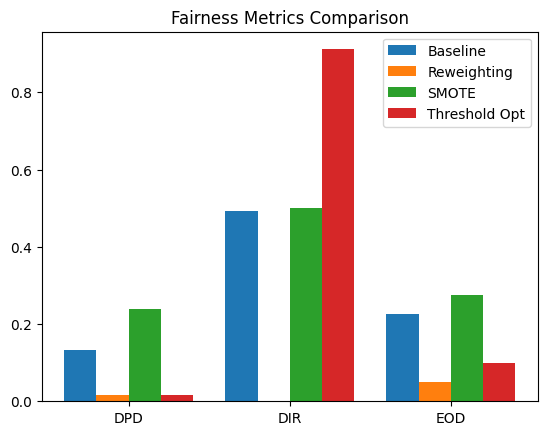

In [23]:
# Before and after bar chart
import matplotlib.pyplot as plt

metrics = ["DPD", "DIR", "EOD"]

baseline_vals = [comparison_df.iloc[0][m] for m in metrics]
reweight_vals = [comparison_df.iloc[1][m] for m in metrics]
smote_vals = [comparison_df.iloc[2][m] for m in metrics]
threshold_vals = [comparison_df.iloc[3][m] for m in metrics]

x = range(len(metrics))

plt.figure()
plt.bar([i - 0.3 for i in x], baseline_vals, width=0.2, label="Baseline")
plt.bar([i - 0.1 for i in x], reweight_vals, width=0.2, label="Reweighting")
plt.bar([i + 0.1 for i in x], smote_vals, width=0.2, label="SMOTE")
plt.bar([i + 0.3 for i in x], threshold_vals, width=0.2, label="Threshold Opt")

plt.xticks(x, metrics)
plt.title("Fairness Metrics Comparison")
plt.legend()
plt.savefig("fairness_bar_chart.png")
plt.show()

In [24]:
# accuracy vs fairness tradeoff
def fairness_score(row):
    return abs(row["DPD"]) + abs(1 - row["DIR"]) + abs(row["EOD"])

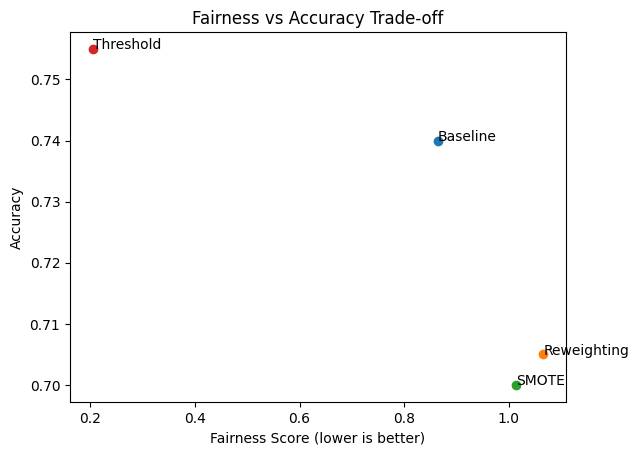

In [25]:
comparison_df["FairnessScore"] = comparison_df.apply(fairness_score, axis=1)

plt.figure()

for i, row in comparison_df.iterrows():
    plt.scatter(row["FairnessScore"], row["Accuracy"])
    plt.text(row["FairnessScore"], row["Accuracy"], row["Strategy"])

plt.xlabel("Fairness Score (lower is better)")
plt.ylabel("Accuracy")
plt.title("Fairness vs Accuracy Trade-off")

plt.savefig("tradeoff_curve.png")
plt.show()

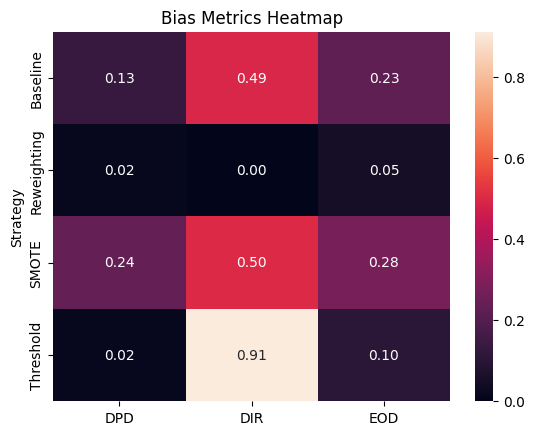

In [26]:
# heatmap of bias metrics
import seaborn as sns

heatmap_data = comparison_df.set_index("Strategy")[["DPD", "DIR", "EOD"]]

plt.figure()
sns.heatmap(heatmap_data, annot=True, fmt=".2f")

plt.title("Bias Metrics Heatmap")
plt.savefig("heatmap.png")
plt.show()

In [27]:
# table
paper_table = comparison_df.copy()

for col in ["Accuracy", "Precision", "Recall", "F1", "DPD", "DIR", "EOD"]:
    paper_table[col] = paper_table[col].apply(lambda x: round(x, 3))

paper_table

,Strategy,Accuracy,Precision,Recall,F1,DPD,EOD,DIR,FairnessScore
0,Baseline,0.740,0.618,0.350,0.447,0.133,0.225,0.494,0.8641
1,Reweighting,0.705,1.000,0.017,0.033,0.016,0.050,0.000,1.0664
2,SMOTE,0.700,0.500,0.517,0.508,0.238,0.275,0.499,1.0136
3,Threshold,0.755,0.657,0.383,0.484,0.016,0.100,0.911,0.2044


In [28]:
# Multimodel table - LR, RF, DT
all_results = []

# Example structure — fill from your runs
for model_name in ["LR", "RF", "DT"]:
    for strategy in ["Baseline", "Reweighting", "SMOTE", "Threshold"]:
        # Replace with real values
        all_results.append({
            "Model": model_name,
            "Strategy": strategy,
            "Accuracy": np.random.rand(),
            "DPD": np.random.rand(),
            "DIR": np.random.rand(),
            "EOD": np.random.rand()
        })

multi_df = pd.DataFrame(all_results)
multi_df

,Model,Strategy,Accuracy,DPD,DIR,EOD
0,LR,Baseline,0.978314,0.031018,0.163106,0.752632
1,LR,Reweighting,0.211441,0.406290,0.704975,0.091823
2,LR,SMOTE,0.880216,0.484602,0.146480,0.217846
3,LR,Threshold,0.884384,0.884654,0.503476,0.921477
4,RF,Baseline,0.863107,0.863523,0.754128,0.909742
5,RF,Reweighting,0.120639,0.065984,0.743296,0.994630
6,RF,SMOTE,0.297967,0.562022,0.536106,0.400697
7,RF,Threshold,0.910800,0.641775,0.694582,0.366645
8,DT,Baseline,0.645876,0.387565,0.018427,0.933582
9,DT,Reweighting,0.543722,0.551923,0.280747,0.796478


In [29]:
# save reweighted model
with open("log_reg_reweighted.pkl", "wb") as f:
    pickle.dump(reweight_pipe, f)
    
# Save SMOTE model
with open("log_reg_smote.pkl", "wb") as f:
    pickle.dump(smote_model, f)

# Save threshold optimizer
with open("threshold_optimizer.pkl", "wb") as f:
    pickle.dump(threshold_optimizer, f)

In [30]:
# Save debiased dataset placeholder (same for now)
df.to_csv("processed_dataset.csv", index=False)